In [106]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

pd.set_option('future.no_silent_downcasting', True)

df = pd.read_csv('processed_data.csv', index_col=0)
df.head()

,Age (>35),Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,Country,PrevSalary,Skills,Num_of_skills,Employed
0,0,0,Master,1,1,0,1,7,Sweden,51552,C++;Python;Git;PostgreSQL,4,0
1,0,0,Undergraduate,1,1,0,1,12,Spain,46482,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1
2,0,0,Master,1,1,0,1,15,Germany,77290,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0
3,0,0,Undergraduate,1,1,0,1,9,Canada,46135,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0
4,1,0,PhD,0,1,0,0,40,Singapore,160932,C++;Python,2,0


In [107]:
# Dropping string columns
df = df.drop(columns=['EdLevel','Country','Skills'])

In [108]:
df.head()

,Age (>35),Accessibility,Employment,Gender,MentalHealth,MainBranch,YearsCode,PrevSalary,Num_of_skills,Employed
0,0,0,1,1,0,1,7,51552,4,0
1,0,0,1,1,0,1,12,46482,12,1
2,0,0,1,1,0,1,15,77290,7,0
3,0,0,1,1,0,1,9,46135,13,0
4,1,0,0,1,0,0,40,160932,2,0


In [109]:
y = df['Employed']
X = df.drop(columns=['Employed'], axis=1)

## Splitting and Normalizing the Data

In [110]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# create a scaler object
scaler = StandardScaler()

feature_names = X.columns 
gender = X['Gender']

X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X, y, gender, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Evaluate Fairness for original data

Accuracy for female: 0.7994

Confusion Matrix for Logistic Regression (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,360,112
Actual Not Employed,87,433


Accuracy for male: 0.783

Confusion Matrix for Logistic Regression (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5953,1484
Actual Not Employed,1486,4764



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.76,0.17,0.83,0.24
Male,0.80,0.24,0.76,0.20


Model Accuracy (Logistic Regression): 0.784
Model Precision score (Logistic Regression): 0.801
Model Recall score (Logistic Regression): 0.798
Model F1 score (Logistic Regression): 0.799


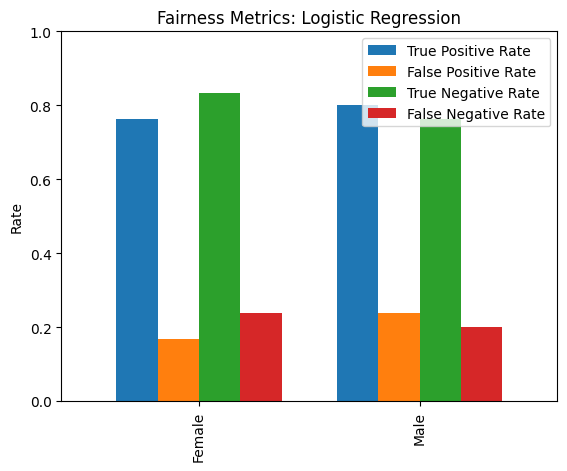

Accuracy for female: 0.7621

Confusion Matrix for Random Forest (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,359,113
Actual Not Employed,123,397


Accuracy for male: 0.7414

Confusion Matrix for Random Forest (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5726,1711
Actual Not Employed,1829,4421



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.76,0.24,0.76,0.24
Male,0.77,0.29,0.71,0.23


Model Accuracy (Random Forest): 0.743
Model Precision score (Random Forest): 0.757
Model Recall score (Random Forest): 0.769
Model F1 score (Random Forest): 0.763


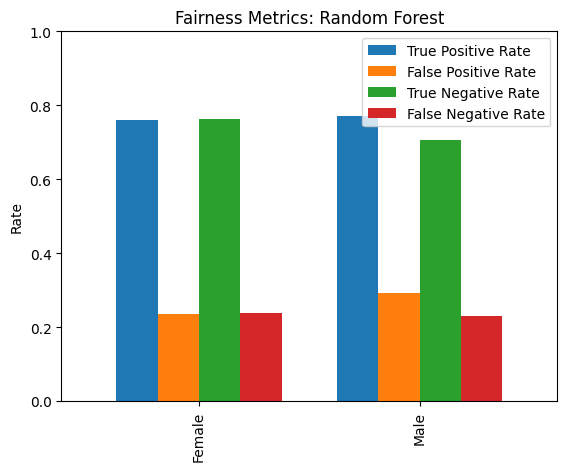

Accuracy for female: 0.7944

Confusion Matrix for XGBoost (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,377,95
Actual Not Employed,109,411


Accuracy for male: 0.7752

Confusion Matrix for XGBoost (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,6105,1332
Actual Not Employed,1745,4505



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.80,0.21,0.79,0.20
Male,0.82,0.28,0.72,0.18


Model Accuracy (XGBoost): 0.776
Model Precision score (XGBoost): 0.778
Model Recall score (XGBoost): 0.82
Model F1 score (XGBoost): 0.798


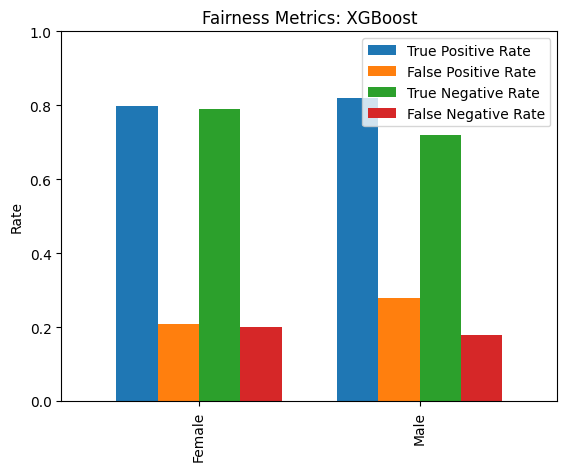

Accuracy for female: 0.7984

Confusion Matrix for SVM (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,358,114
Actual Not Employed,86,434


Accuracy for male: 0.7824

Confusion Matrix for SVM (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5915,1522
Actual Not Employed,1456,4794



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.76,0.17,0.83,0.24
Male,0.80,0.23,0.77,0.20


Model Accuracy (SVM): 0.784
Model Precision score (SVM): 0.803
Model Recall score (SVM): 0.793
Model F1 score (SVM): 0.798


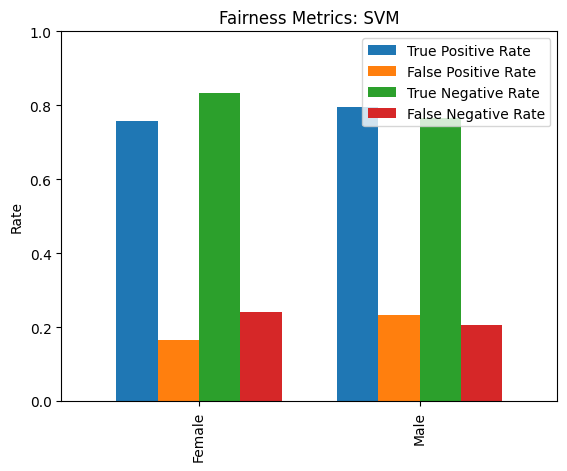

Accuracy for female: 0.7812

Confusion Matrix for KNN (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,352,120
Actual Not Employed,97,423


Accuracy for male: 0.7696

Confusion Matrix for KNN (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5968,1469
Actual Not Employed,1685,4565



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.75,0.19,0.81,0.25
Male,0.80,0.27,0.73,0.20


Model Accuracy (KNN): 0.77
Model Precision score (KNN): 0.78
Model Recall score (KNN): 0.799
Model F1 score (KNN): 0.789


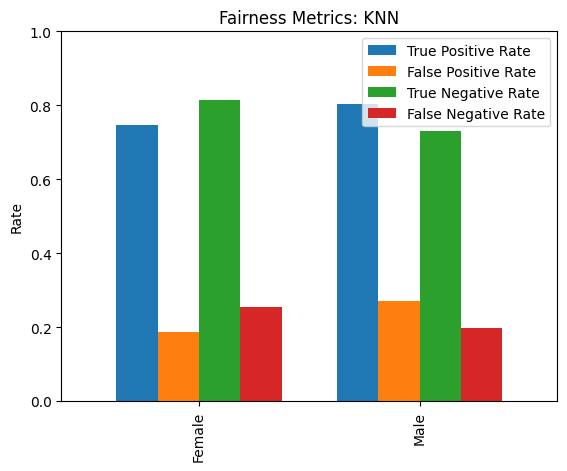

Accuracy for female: 0.7762

Confusion Matrix for Naive Bayes (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,321,151
Actual Not Employed,71,449


Accuracy for male: 0.7622

Confusion Matrix for Naive Bayes (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5221,2216
Actual Not Employed,1039,5211



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.68,0.14,0.86,0.32
Male,0.70,0.17,0.83,0.30


Model Accuracy (Naive Bayes): 0.763
Model Precision score (Naive Bayes): 0.833
Model Recall score (Naive Bayes): 0.701
Model F1 score (Naive Bayes): 0.761


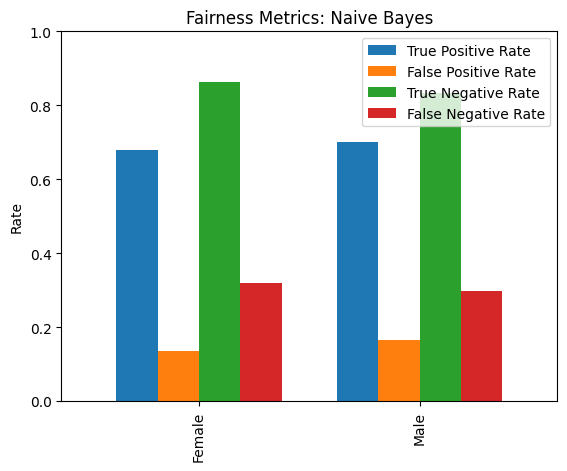

In [111]:
def evaluate_fairness(y_true, y_pred, model_name):
    # Build results dataframe
    # We are using y_test.index to ensure that we pull the correct Gender from the original dataset
    results = pd.DataFrame({
        "y_true": y_true.values, 
        "y_pred": y_pred,
        "Gender": df.loc[y_test.index, "Gender"].values
    })

    # 2) Initialize storage for this specific model
    gender_groups = [0, 1] # 0: Female, 1: Male
    genders_order = ["Female", "Male"]
    confusion_tables = {}
    current_sp = []
    current_tpr = []
    current_fpr = []
    rates = {}

    # 3) Process each gender
    for g in gender_groups:
        subset = results[results["Gender"] == g]
        gender_label = "Female" if g == 0 else "Male"
        
        # Calculate Confusion Matrix
        cm = confusion_matrix(subset["y_true"], subset["y_pred"], labels=[1, 0])
        confusion_tables[gender_label] = pd.DataFrame(
            cm, 
            index=["Actual Employed", "Actual Not Employed"],
            columns=["Predicted Employed", "Predicted Not Employed"]
        )
        
        # Extract values
        tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
        
        # Calculate Metrics
        total = tp + tn + fp + fn
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan

        gender_acc = (tp + tn) / total
        print(f"Accuracy for {gender_label.lower()}: {round(gender_acc, 4)}")
        
        # Store for the global lists (sp_lg, etc.)
        current_sp.append((tp + fp) / total)
        current_tpr.append(tpr)
        current_fpr.append(fpr)

        rates[gender_label] = {
            "True Positive Rate": tpr,
            "False Positive Rate": fpr,
            "True Negative Rate": tn / (tn + fp) if (tn + fp) else np.nan,
            "False Negative Rate": fn / (fn + tp) if (fn + tp) else np.nan
        }
        
        print(f"\nConfusion Matrix for {model_name} (Gender = {gender_label})")
        display(confusion_tables[gender_label])

    # Display Rates Table
    df_rates = pd.DataFrame(rates).T
    print("\nRates:")
    display(df_rates.round(2))

    # Show model accuracy
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f_score = f1_score(y_test, y_pred)
    print(f'Model Accuracy ({model_name}): {round(accuracy, 3)}')
    print(f'Model Precision score ({model_name}): {round(precision, 3)}')
    print(f'Model Recall score ({model_name}): {round(recall, 3)}')
    print(f'Model F1 score ({model_name}): {round(f_score, 3)}')
    #  Visualization
    df_rates = pd.DataFrame(rates).T
    ax = df_rates.plot(kind="bar", width=0.75)
    plt.title(f"Fairness Metrics: {model_name}")
    plt.ylabel("Rate")
    plt.ylim(0, 1)
    plt.show()

    # Return the metrics so you can use them in your fairness measurements
    return current_sp, current_tpr, current_fpr

# Logistic Regression
lr_model = LogisticRegression(random_state=42).fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
sp_lg, TPR_lr, FPR_lr = evaluate_fairness(y_test, y_pred_lr, "Logistic Regression")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
sp_rf, TPR_rf, FPR_rf = evaluate_fairness(y_test, y_pred_rf, "Random Forest")

'''
# Gradient Boosting
gbc = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42).fit(X_train_scaled, y_train)
y_pred_gbc = gbc.predict(X_test_scaled)
sp_gbc, TPR_gbc, FPR_gbc = evaluate_fairness(y_test, y_pred_gbc, "Gradient Boosting")
'''

#XGBoost
xgb = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
sp_xgb, TPR_xgb, FPR_xgb = evaluate_fairness(y_test, y_pred_xgb, "XGBoost")

#SVM
svm = LinearSVC(random_state=42, dual=False).fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
sp_svm, TPR_svm, FPR_svm = evaluate_fairness(y_test, y_pred_svm, "SVM")

#KNN
knn = KNeighborsClassifier(n_neighbors=17).fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
sp_knn, TPR_knn, FPR_knn = evaluate_fairness(y_test, y_pred_knn, "KNN")

#Naive bayes
nb = GaussianNB().fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
sp_nb, TPR_nb, FPR_nb = evaluate_fairness(y_test, y_pred_nb, "Naive Bayes")

# Statistical Parity Difference

### $$SPD = Pr(\hat{Y} = 1 \mid D = \text{unprivileged}) - Pr(\hat{Y} = 1 \mid D = \text{privileged})$$

In [112]:
SPD_orig_lg = round(sp_lg[0] - sp_lg[1], 4)
SPD_orig_rf = round(sp_rf[0] - sp_rf[1], 4)
#SPD_orig_gbc = round(sp_gbc[0] - sp_gbc[1], 4)
SPD_orig_xgb = round(sp_xgb[0] - sp_xgb[1], 4)
SPD_orig_svm = round(sp_svm[0] - sp_svm[1], 4)
SPD_orig_knn = round(sp_knn[0] - sp_knn[1], 4)
SPD_orig_nb = round(sp_nb[0] - sp_nb[1], 4)
print(f'Logistic Regression -> {SPD_orig_lg} \nRandom Forest -> {SPD_orig_rf} \nXGBoost -> {SPD_orig_xgb} \nSVM -> {SPD_orig_svm} \nKNN -> {SPD_orig_knn} \nNaive Bayes -> {SPD_orig_nb}')

Logistic Regression -> -0.0929 
Random Forest -> -0.0661 
XGBoost -> -0.0836 
SVM -> -0.091 
KNN -> -0.1065 
Naive Bayes -> -0.0622


# Disparate Impact
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [113]:
DI_orig_lg = round(sp_lg[0] / sp_lg[1], 4)
DI_orig_rf = round(sp_rf[0] / sp_rf[1], 4)
#DI_orig_gbc = round(sp_gbc[0] / sp_gbc[1], 4)
DI_orig_xgb = round(sp_xgb[0] / sp_xgb[1], 4)
DI_orig_svm = round(sp_svm[0] / sp_svm[1], 4)
DI_orig_knn = round(sp_knn[0] / sp_knn[1], 4)
DI_orig_nb = round(sp_nb[0] / sp_nb[1], 4)
print(f'Logistic Regression -> {DI_orig_lg} \nRandom Forest -> {DI_orig_rf} \nXGBoost -> {DI_orig_xgb} \nSVM -> {DI_orig_svm} \nKNN -> {DI_orig_knn}  \nNaive Bayes -> {DI_orig_nb}')

Logistic Regression -> 0.8291 
Random Forest -> 0.8803 
XGBoost -> 0.8542 
SVM -> 0.8311 
KNN -> 0.8095  
Naive Bayes -> 0.864


# Equal Opportunity
### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [114]:
EOD_orig_lg = round(TPR_lr[0] - TPR_lr[1], 4)
EOD_orig_rf = round(TPR_rf[0] - TPR_rf[1], 4)
#EOD_orig_gbc = round(TPR_gbc[0] - TPR_gbc[1], 4)
EOD_orig_xgb = round(TPR_xgb[0] - TPR_xgb[1], 4)
EOD_orig_svm = round(TPR_svm[0] - TPR_svm[1], 4)
EOD_orig_knn = round(TPR_knn[0] - TPR_knn[1], 4)
EOD_orig_nb = round(TPR_nb[0] - TPR_nb[1], 4)
print(f'Logistic Regression -> {EOD_orig_lg} \nRandom Forest -> {EOD_orig_rf} \nXGBoost -> {EOD_orig_xgb} \nSVM -> {EOD_orig_svm} \nKNN -> {EOD_orig_knn} \nNaive Bayes -> {EOD_orig_nb}')

Logistic Regression -> -0.0377 
Random Forest -> -0.0093 
XGBoost -> -0.0222 
SVM -> -0.0369 
KNN -> -0.0567 
Naive Bayes -> -0.0219


# Equalized Odds

### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [115]:
AAOD_orig_lg = round(((TPR_lr[0] - TPR_lr[1]) + (FPR_lr[0] - FPR_lr[1])) / 2, 4)
AAOD_orig_rf = round(((TPR_rf[0] - TPR_rf[1]) + (FPR_rf[0] - FPR_rf[1])) / 2, 4)
#AAOD_orig_gbc = round(((TPR_gbc[0] - TPR_gbc[1]) + (FPR_gbc[0] - FPR_gbc[1])) / 2, 4)
AAOD_orig_xgb = round(((TPR_xgb[0] - TPR_xgb[1]) + (FPR_xgb[0] - FPR_xgb[1])) / 2, 4)
AAOD_orig_svm = round(((TPR_svm[0] - TPR_svm[1]) + (FPR_svm[0] - FPR_svm[1])) / 2, 4)
AAOD_orig_knn = round(((TPR_knn[0] - TPR_knn[1]) + (FPR_knn[0] - FPR_knn[1])) / 2, 4)
AAOD_orig_nb = round(((TPR_nb[0] - TPR_nb[1]) + (FPR_nb[0] - FPR_nb[1])) / 2, 4)
print(f'Logistic Regression -> {AAOD_orig_lg} \nRandom Forest -> {AAOD_orig_rf} \nXGBoost -> {AAOD_orig_xgb} \nSVM -> {AAOD_orig_svm} \nKNN -> {AAOD_orig_knn}  \nNaive Bayes -> {AAOD_orig_nb}')

Logistic Regression -> -0.0541 
Random Forest -> -0.0327 
XGBoost -> -0.0459 
SVM -> -0.0522 
KNN -> -0.0699  
Naive Bayes -> -0.0258


# Bias Mitigation

## Pre-Processing (Removing Gender Attribute)  'Fairness through Blindness'.

In [116]:
X_train_blind = np.delete(X_train_scaled, 3, axis=1)
X_test_blind = np.delete(X_test_scaled, 3, axis=1)

Accuracy for female: 0.8004

Confusion Matrix for Logistic Regression (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,368,104
Actual Not Employed,94,426


Accuracy for male: 0.7828

Confusion Matrix for Logistic Regression (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5944,1493
Actual Not Employed,1480,4770



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.78,0.18,0.82,0.22
Male,0.80,0.24,0.76,0.20


Model Accuracy (Logistic Regression): 0.784
Model Precision score (Logistic Regression): 0.8
Model Recall score (Logistic Regression): 0.798
Model F1 score (Logistic Regression): 0.799


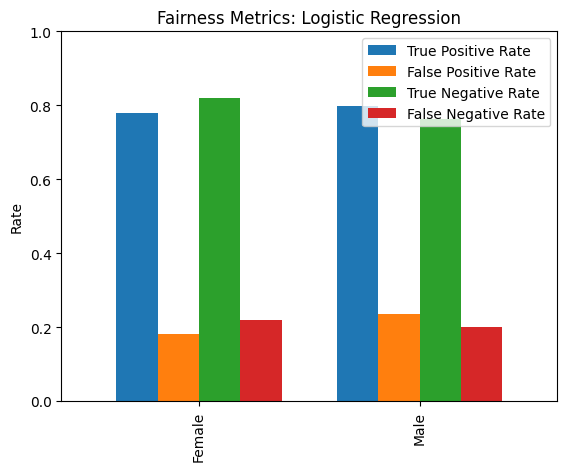

Accuracy for female: 0.7591

Confusion Matrix for Random Forest (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,348,124
Actual Not Employed,115,405


Accuracy for male: 0.7389

Confusion Matrix for Random Forest (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5705,1732
Actual Not Employed,1841,4409



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.74,0.22,0.78,0.26
Male,0.77,0.29,0.71,0.23


Model Accuracy (Random Forest): 0.74
Model Precision score (Random Forest): 0.756
Model Recall score (Random Forest): 0.765
Model F1 score (Random Forest): 0.761


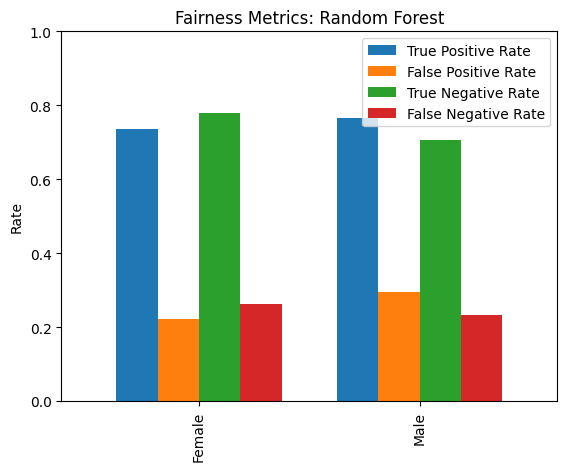

Accuracy for female: 0.7954

Confusion Matrix for XGBoost (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,376,96
Actual Not Employed,107,413


Accuracy for male: 0.7734

Confusion Matrix for XGBoost (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,6061,1376
Actual Not Employed,1725,4525



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.80,0.21,0.79,0.20
Male,0.81,0.28,0.72,0.19


Model Accuracy (XGBoost): 0.775
Model Precision score (XGBoost): 0.778
Model Recall score (XGBoost): 0.814
Model F1 score (XGBoost): 0.796


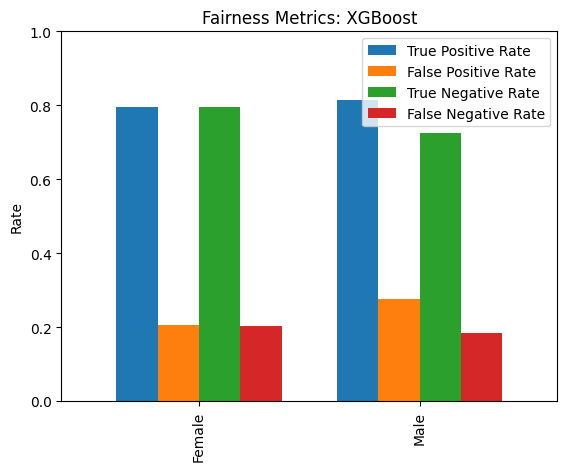

Accuracy for female: 0.8024

Confusion Matrix for SVM (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,368,104
Actual Not Employed,92,428


Accuracy for male: 0.7821

Confusion Matrix for SVM (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5906,1531
Actual Not Employed,1451,4799



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.78,0.18,0.82,0.22
Male,0.79,0.23,0.77,0.21


Model Accuracy (SVM): 0.784
Model Precision score (SVM): 0.803
Model Recall score (SVM): 0.793
Model F1 score (SVM): 0.798


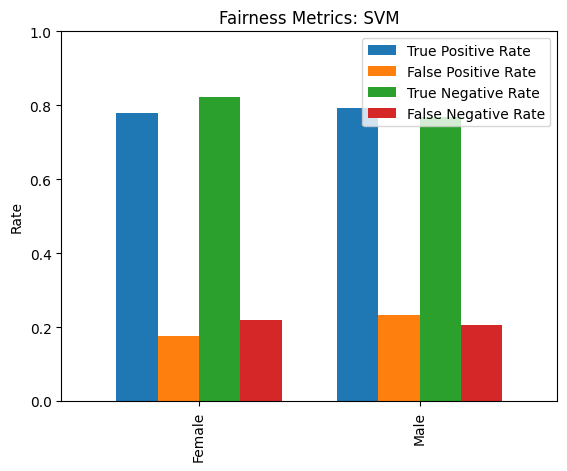

Accuracy for female: 0.7782

Confusion Matrix for KNN (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,368,104
Actual Not Employed,116,404


Accuracy for male: 0.7704

Confusion Matrix for KNN (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5982,1455
Actual Not Employed,1688,4562



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.78,0.22,0.78,0.22
Male,0.80,0.27,0.73,0.20


Model Accuracy (KNN): 0.771
Model Precision score (KNN): 0.779
Model Recall score (KNN): 0.803
Model F1 score (KNN): 0.791


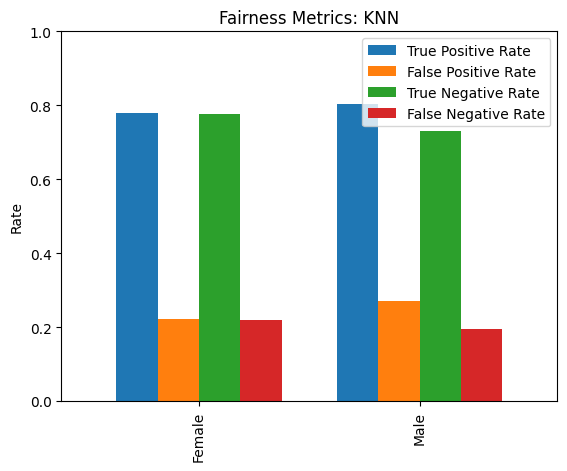

Accuracy for female: 0.7762

Confusion Matrix for Naive Bayes (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,321,151
Actual Not Employed,71,449


Accuracy for male: 0.7622

Confusion Matrix for Naive Bayes (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5221,2216
Actual Not Employed,1039,5211



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.68,0.14,0.86,0.32
Male,0.70,0.17,0.83,0.30


Model Accuracy (Naive Bayes): 0.763
Model Precision score (Naive Bayes): 0.833
Model Recall score (Naive Bayes): 0.701
Model F1 score (Naive Bayes): 0.761


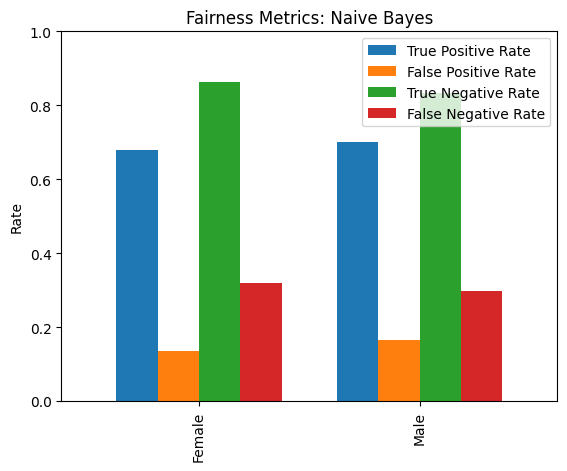

In [117]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42).fit(X_train_blind, y_train)
y_pred_lr = lr_model.predict(X_test_blind)
sp_lg, TPR_lr, FPR_lr = evaluate_fairness(y_test, y_pred_lr, "Logistic Regression")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_blind, y_train)
y_pred_rf = rf_model.predict(X_test_blind)
sp_rf, TPR_rf, FPR_rf = evaluate_fairness(y_test, y_pred_rf, "Random Forest")

'''
# Gradient Boosting
gbc = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42).fit(X_train_blind, y_train)
y_pred_gbc = gbc.predict(X_test_blind)
sp_gbc, TPR_gbc, FPR_gbc = evaluate_fairness(y_test, y_pred_gbc, "Gradient Boosting")
'''

#XGBoost
xgb = XGBClassifier(n_estimators=300, random_state=42).fit(X_train_blind, y_train)
y_pred_xgb = xgb.predict(X_test_blind)
sp_xgb, TPR_xgb, FPR_xgb = evaluate_fairness(y_test, y_pred_xgb, "XGBoost")

#SVM
svm = LinearSVC(random_state=42, dual=False).fit(X_train_blind, y_train)
y_pred_svm = svm.predict(X_test_blind)
sp_svm, TPR_svm, FPR_svm = evaluate_fairness(y_test, y_pred_svm, "SVM")

#KNN
knn = KNeighborsClassifier(n_neighbors=17).fit(X_train_blind, y_train)
y_pred_knn = knn.predict(X_test_blind)
sp_knn, TPR_knn, FPR_knn = evaluate_fairness(y_test, y_pred_knn, "KNN")

#Naive bayes
nb = GaussianNB().fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
sp_nb, TPR_nb, FPR_nb = evaluate_fairness(y_test, y_pred_nb, "Naive Bayes")

# Statistical Parity Difference
### $$SPD = Pr(\hat{Y} = 1 \mid D = \text{unprivileged}) - Pr(\hat{Y} = 1 \mid D = \text{privileged})$$

In [118]:
SPD_pre1_lg = round(sp_lg[0] - sp_lg[1], 4)
SPD_pre1_rf = round(sp_rf[0] - sp_rf[1], 4)
#SPD_pre1_gbc = round(sp_gbc[0] - sp_gbc[1], 4)
SPD_pre1_xgb = round(sp_xgb[0] - sp_xgb[1], 4)
SPD_pre1_svm = round(sp_svm[0] - sp_svm[1], 4)
SPD_pre1_knn = round(sp_knn[0] - sp_knn[1], 4)
SPD_pre1_nb = round(sp_nb[0] - sp_nb[1], 4)
print(f'Logistic Regression -> {SPD_pre1_lg} \nRandom Forest -> {SPD_pre1_rf} \nXGBoost -> {SPD_pre1_xgb} \nSVM -> {SPD_pre1_svm} \nKNN -> {SPD_pre1_knn} \nNaive Bayes -> {SPD_pre1_nb}')

Logistic Regression -> -0.0767 
Random Forest -> -0.0846 
XGBoost -> -0.082 
SVM -> -0.0738 
KNN -> -0.0725 
Naive Bayes -> -0.0622


# Disparate Impact
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [119]:
DI_pre1_lg = round(sp_lg[0] / sp_lg[1], 4)
DI_pre1_rf = round(sp_rf[0] / sp_rf[1], 4)
#DI_pre1_gbc = round(sp_gbc[0] / sp_gbc[1], 4)
DI_pre1_xgb = round(sp_xgb[0] / sp_xgb[1], 4)
DI_pre1_svm = round(sp_svm[0] / sp_svm[1], 4)
DI_pre1_knn = round(sp_knn[0] / sp_knn[1], 4)
DI_pre1_nb = round(sp_nb[0] / sp_nb[1], 4)
print(f'Logistic Regression -> {DI_pre1_lg} \nRandom Forest -> {DI_pre1_rf} \nXGBoost -> {DI_pre1_xgb} \nSVM -> {DI_pre1_svm} \nKNN -> {DI_pre1_knn}  \nNaive Bayes -> {DI_pre1_nb}')

Logistic Regression -> 0.8586 
Random Forest -> 0.8466 
XGBoost -> 0.8559 
SVM -> 0.8627 
KNN -> 0.8707  
Naive Bayes -> 0.864


# Equal Opportunity
### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [120]:
EOD_pre1_lg = round(TPR_lr[0] - TPR_lr[1], 4)
EOD_pre1_rf = round(TPR_rf[0] - TPR_rf[1], 4)
#EOD_pre1_gbc = round(TPR_gbc[0] - TPR_gbc[1], 4)
EOD_pre1_xgb = round(TPR_xgb[0] - TPR_xgb[1], 4)
EOD_pre1_svm = round(TPR_svm[0] - TPR_svm[1], 4)
EOD_pre1_knn = round(TPR_knn[0] - TPR_knn[1], 4)
EOD_pre1_nb = round(TPR_nb[0] - TPR_nb[1], 4)
print(f'Logistic Regression -> {EOD_pre1_lg} \nRandom Forest -> {EOD_pre1_rf} \nXGBoost -> {EOD_pre1_xgb} \nSVM -> {EOD_pre1_svm} \nKNN -> {EOD_pre1_knn} \nNaive Bayes -> {EOD_pre1_nb}')

Logistic Regression -> -0.0196 
Random Forest -> -0.0298 
XGBoost -> -0.0184 
SVM -> -0.0145 
KNN -> -0.0247 
Naive Bayes -> -0.0219


# Equalized Odds
### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [121]:
AAOD_pre1_lg = round(((TPR_lr[0] - TPR_lr[1]) + (FPR_lr[0] - FPR_lr[1])) / 2, 4)
AAOD_pre1_rf = round(((TPR_rf[0] - TPR_rf[1]) + (FPR_rf[0] - FPR_rf[1])) / 2, 4)
#AAOD_pre1_gbc = round(((TPR_gbc[0] - TPR_gbc[1]) + (FPR_gbc[0] - FPR_gbc[1])) / 2, 4)
AAOD_pre1_xgb = round(((TPR_xgb[0] - TPR_xgb[1]) + (FPR_xgb[0] - FPR_xgb[1])) / 2, 4)
AAOD_pre1_svm = round(((TPR_svm[0] - TPR_svm[1]) + (FPR_svm[0] - FPR_svm[1])) / 2, 4)
AAOD_pre1_knn = round(((TPR_knn[0] - TPR_knn[1]) + (FPR_knn[0] - FPR_knn[1])) / 2, 4)
AAOD_pre1_nb = round(((TPR_nb[0] - TPR_nb[1]) + (FPR_nb[0] - FPR_nb[1])) / 2, 4)
print(f'Logistic Regression -> {AAOD_pre1_lg} \nRandom Forest -> {AAOD_pre1_rf} \nXGBoost -> {AAOD_pre1_xgb} \nSVM -> {AAOD_pre1_svm} \nKNN -> {AAOD_pre1_knn}  \nNaive Bayes -> {AAOD_pre1_nb}')

Logistic Regression -> -0.0378 
Random Forest -> -0.0516 
XGBoost -> -0.0443 
SVM -> -0.0349 
KNN -> -0.0358  
Naive Bayes -> -0.0258


## Pre-Processing (Reweighting)

In [122]:
from sklearn.utils.class_weight import compute_sample_weight

groups = [f"{g}_{y}" for g, y in zip(gender_train, y_train)]

fairness_weights = compute_sample_weight('balanced', groups)

Accuracy for female: 0.8004

Confusion Matrix for Logistic Regression (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,369,103
Actual Not Employed,95,425


Accuracy for male: 0.7758

Confusion Matrix for Logistic Regression (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5636,1801
Actual Not Employed,1267,4983



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.78,0.18,0.82,0.22
Male,0.76,0.20,0.80,0.24


Model Accuracy (Logistic Regression): 0.778
Model Precision score (Logistic Regression): 0.815
Model Recall score (Logistic Regression): 0.759
Model F1 score (Logistic Regression): 0.786


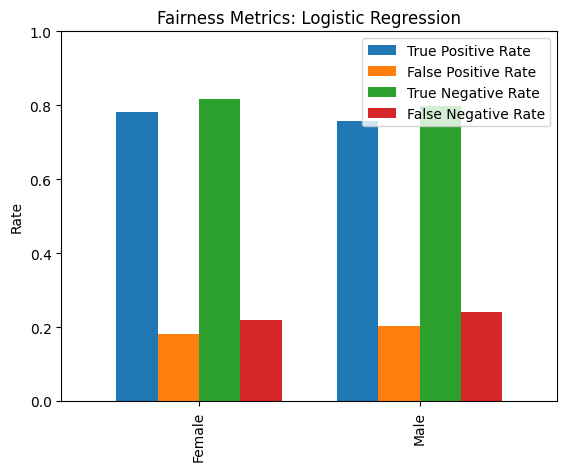

Accuracy for female: 0.7681

Confusion Matrix for Random Forest (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,361,111
Actual Not Employed,119,401


Accuracy for male: 0.7422

Confusion Matrix for Random Forest (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5735,1702
Actual Not Employed,1827,4423



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.76,0.23,0.77,0.24
Male,0.77,0.29,0.71,0.23


Model Accuracy (Random Forest): 0.744
Model Precision score (Random Forest): 0.758
Model Recall score (Random Forest): 0.771
Model F1 score (Random Forest): 0.764


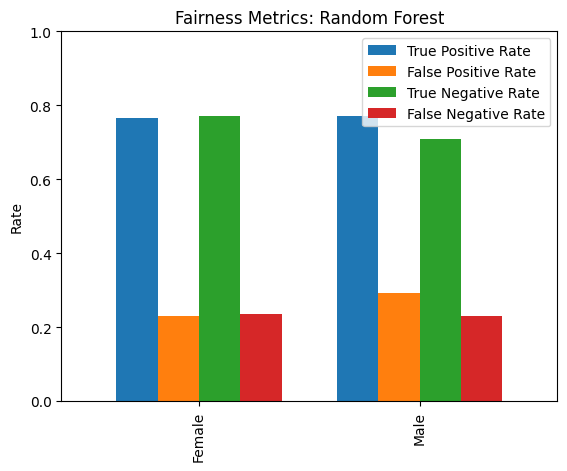

Accuracy for female: 0.7843

Confusion Matrix for XGBoost (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,375,97
Actual Not Employed,117,403


Accuracy for male: 0.78

Confusion Matrix for XGBoost (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5920,1517
Actual Not Employed,1494,4756



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.79,0.22,0.78,0.21
Male,0.80,0.24,0.76,0.20


Model Accuracy (XGBoost): 0.78
Model Precision score (XGBoost): 0.796
Model Recall score (XGBoost): 0.796
Model F1 score (XGBoost): 0.796


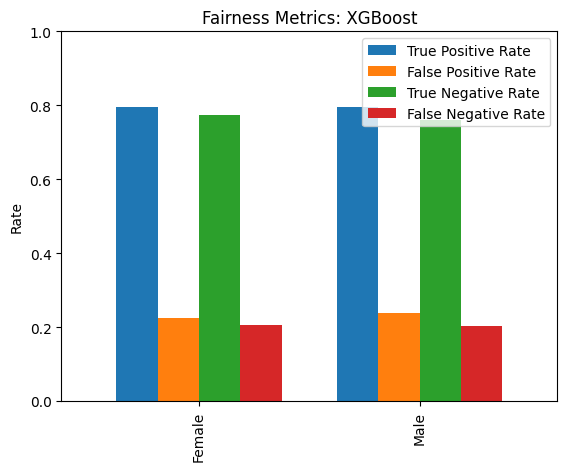

Accuracy for female: 0.8014

Confusion Matrix for SVM (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,368,104
Actual Not Employed,93,427


Accuracy for male: 0.7747

Confusion Matrix for SVM (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5609,1828
Actual Not Employed,1255,4995



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.78,0.18,0.82,0.22
Male,0.75,0.20,0.80,0.25


Model Accuracy (SVM): 0.777
Model Precision score (SVM): 0.816
Model Recall score (SVM): 0.756
Model F1 score (SVM): 0.785


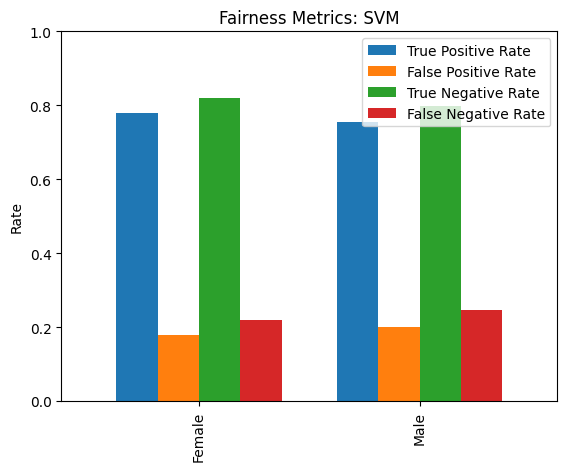

Accuracy for female: 0.75

Confusion Matrix for KNN (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,346,126
Actual Not Employed,122,398


Accuracy for male: 0.7397

Confusion Matrix for KNN (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5687,1750
Actual Not Employed,1813,4437



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.73,0.23,0.77,0.27
Male,0.76,0.29,0.71,0.24


Model Accuracy (KNN): 0.74
Model Precision score (KNN): 0.757
Model Recall score (KNN): 0.763
Model F1 score (KNN): 0.76


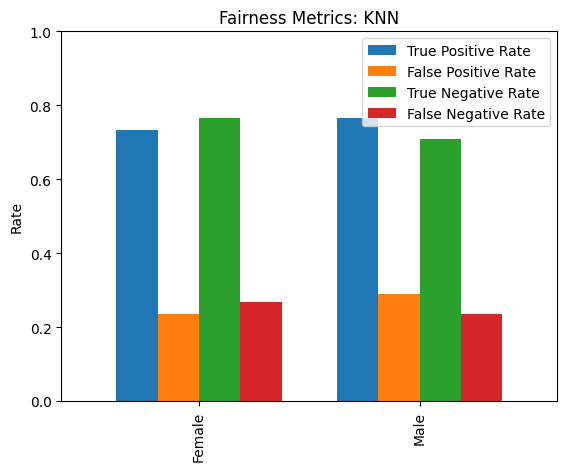

Accuracy for female: 0.7772

Confusion Matrix for Naive Bayes (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,319,153
Actual Not Employed,68,452


Accuracy for male: 0.7587

Confusion Matrix for Naive Bayes (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5100,2337
Actual Not Employed,966,5284



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.68,0.13,0.87,0.32
Male,0.69,0.15,0.85,0.31


Model Accuracy (Naive Bayes): 0.76
Model Precision score (Naive Bayes): 0.84
Model Recall score (Naive Bayes): 0.685
Model F1 score (Naive Bayes): 0.755


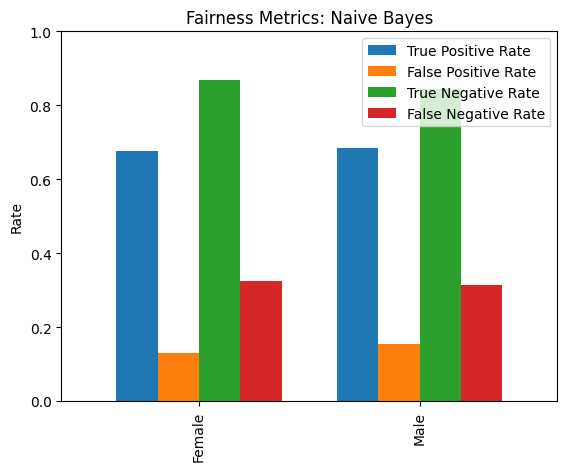

In [123]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42).fit(X_train_scaled, y_train, sample_weight=fairness_weights)
y_pred_lr = lr_model.predict(X_test_scaled)
sp_lg, TPR_lr, FPR_lr = evaluate_fairness(y_test, y_pred_lr, "Logistic Regression")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_scaled, y_train, sample_weight=fairness_weights)
y_pred_rf = rf_model.predict(X_test_scaled)
sp_rf, TPR_rf, FPR_rf = evaluate_fairness(y_test, y_pred_rf, "Random Forest")

'''
# Gradient Boosting
gbc = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42).fit(X_train_scaled, y_train, sample_weight=fairness_weights)
y_pred_gbc = gbc.predict(X_test_scaled)
sp_gbc, TPR_gbc, FPR_gbc = evaluate_fairness(y_test, y_pred_gbc, "Gradient Boosting")
'''

#XGBoost
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42).fit(X_train_scaled, y_train, sample_weight=fairness_weights)
y_pred_xgb = xgb.predict(X_test_scaled)
sp_xgb, TPR_xgb, FPR_xgb = evaluate_fairness(y_test, y_pred_xgb, "XGBoost")

#SVM
svm = LinearSVC(random_state=42, dual=False).fit(X_train_scaled, y_train, sample_weight=fairness_weights)
y_pred_svm = svm.predict(X_test_scaled)
sp_svm, TPR_svm, FPR_svm = evaluate_fairness(y_test, y_pred_svm, "SVM")

# KNN
knn = KNeighborsClassifier(weights='distance').fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
sp_knn, TPR_knn, FPR_knn = evaluate_fairness(y_test, y_pred_knn, "KNN")

# Naive Bayes
nb = GaussianNB().fit(X_train, y_train, sample_weight=fairness_weights)
y_pred_nb = nb.predict(X_test)
sp_nb, TPR_nb, FPR_nb = evaluate_fairness(y_test, y_pred_nb, "Naive Bayes")

# Statistical Parity Difference

### $$SPD = Pr(\hat{Y} = 1 \mid D = \text{unprivileged}) - Pr(\hat{Y} = 1 \mid D = \text{privileged})$$

In [124]:
SPD_pre2_lg = round(sp_lg[0] - sp_lg[1], 4)
SPD_pre2_rf = round(sp_rf[0] - sp_rf[1], 4)
#SPD_pre2_gbc = round(sp_gbc[0] - sp_gbc[1], 4)
SPD_pre2_xgb = round(sp_xgb[0] - sp_xgb[1], 4)
SPD_pre2_svm = round(sp_svm[0] - sp_svm[1], 4)
SPD_pre2_knn = round(sp_knn[0] - sp_knn[1], 4)
SPD_pre2_nb = round(sp_nb[0] - sp_nb[1], 4)
print(f'Logistic Regression -> {SPD_pre2_lg} \nRandom Forest -> {SPD_pre2_rf} \nXGBoost -> {SPD_pre2_xgb} \nSVM -> {SPD_pre2_svm} \nKNN -> {SPD_pre2_knn} \nNaive Bayes -> {SPD_pre2_nb}')

Logistic Regression -> -0.0366 
Random Forest -> -0.0686 
XGBoost -> -0.0457 
SVM -> -0.0368 
KNN -> -0.0762 
Naive Bayes -> -0.0531


# Disparate Impact
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [125]:
DI_pre2_lg = round(sp_lg[0] / sp_lg[1], 4)
DI_pre2_rf = round(sp_rf[0] / sp_rf[1], 4)
#DI_pre2_gbc = round(sp_gbc[0] / sp_gbc[1], 4)
DI_pre2_xgb = round(sp_xgb[0] / sp_xgb[1], 4)
DI_pre2_svm = round(sp_svm[0] / sp_svm[1], 4)
DI_pre2_knn = round(sp_knn[0] / sp_knn[1], 4)
DI_pre2_nb = round(sp_nb[0] / sp_nb[1], 4)
print(f'Logistic Regression -> {DI_pre2_lg} \nRandom Forest -> {DI_pre2_rf} \nXGBoost -> {DI_pre2_xgb} \nSVM -> {DI_pre2_svm} \nKNN -> {DI_pre2_knn}  \nNaive Bayes -> {DI_pre2_nb}')

Logistic Regression -> 0.9274 
Random Forest -> 0.8758 
XGBoost -> 0.9156 
SVM -> 0.9267 
KNN -> 0.861  
Naive Bayes -> 0.8802


# Equal Opportunity

### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [126]:
EOD_pre2_lg = round(TPR_lr[0] - TPR_lr[1], 4)
EOD_pre2_rf = round(TPR_rf[0] - TPR_rf[1], 4)
#EOD_pre2_gbc = round(TPR_gbc[0] - TPR_gbc[1], 4)
EOD_pre2_xgb = round(TPR_xgb[0] - TPR_xgb[1], 4)
EOD_pre2_svm = round(TPR_svm[0] - TPR_svm[1], 4)
EOD_pre2_knn = round(TPR_knn[0] - TPR_knn[1], 4)
EOD_pre2_nb = round(TPR_nb[0] - TPR_nb[1], 4)
print(f'Logistic Regression -> {EOD_pre2_lg} \nRandom Forest -> {EOD_pre2_rf} \nXGBoost -> {EOD_pre2_xgb} \nSVM -> {EOD_pre2_svm} \nKNN -> {EOD_pre2_knn} \nNaive Bayes -> {EOD_pre2_nb}')

Logistic Regression -> 0.0239 
Random Forest -> -0.0063 
XGBoost -> -0.0015 
SVM -> 0.0255 
KNN -> -0.0316 
Naive Bayes -> -0.0099


# Equalized Odds

### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [127]:
AAOD_pre2_lg = round(((TPR_lr[0] - TPR_lr[1]) + (FPR_lr[0] - FPR_lr[1])) / 2, 4)
AAOD_pre2_rf = round(((TPR_rf[0] - TPR_rf[1]) + (FPR_rf[0] - FPR_rf[1])) / 2, 4)
#AAOD_pre2_gbc = round(((TPR_gbc[0] - TPR_gbc[1]) + (FPR_gbc[0] - FPR_gbc[1])) / 2, 4)
AAOD_pre2_xgb = round(((TPR_xgb[0] - TPR_xgb[1]) + (FPR_xgb[0] - FPR_xgb[1])) / 2, 4)
AAOD_pre2_svm = round(((TPR_svm[0] - TPR_svm[1]) + (FPR_svm[0] - FPR_svm[1])) / 2, 4)
AAOD_pre2_knn = round(((TPR_knn[0] - TPR_knn[1]) + (FPR_knn[0] - FPR_knn[1])) / 2, 4)
AAOD_pre2_nb = round(((TPR_nb[0] - TPR_nb[1]) + (FPR_nb[0] - FPR_nb[1])) / 2, 4)
print(f'Logistic Regression -> {AAOD_pre2_lg} \nRandom Forest -> {AAOD_pre2_rf} \nXGBoost -> {AAOD_pre2_xgb} \nSVM -> {AAOD_pre2_svm} \nKNN -> {AAOD_pre2_knn}  \nNaive Bayes -> {AAOD_pre2_nb}')

Logistic Regression -> 0.002 
Random Forest -> -0.0349 
XGBoost -> -0.0078 
SVM -> 0.0018 
KNN -> -0.0436  
Naive Bayes -> -0.0169


# In Processing (ExponentiatedGradient)

Accuracy for female: 0.8024

Confusion Matrix for Logistic Regression (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,397,75
Actual Not Employed,121,399


Accuracy for male: 0.7813

Confusion Matrix for Logistic Regression (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5899,1538
Actual Not Employed,1455,4795



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.84,0.23,0.77,0.16
Male,0.79,0.23,0.77,0.21


Model Accuracy (Logistic Regression): 0.783
Model Precision score (Logistic Regression): 0.8
Model Recall score (Logistic Regression): 0.796
Model F1 score (Logistic Regression): 0.798


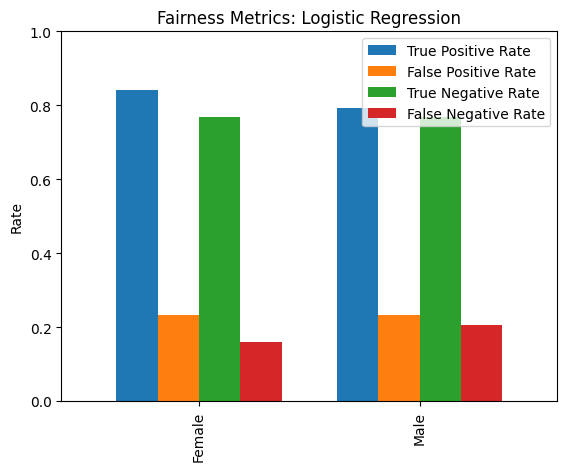

Accuracy for female: 0.7298

Confusion Matrix for Random Forest (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,363,109
Actual Not Employed,159,361


Accuracy for male: 0.7424

Confusion Matrix for Random Forest (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5731,1706
Actual Not Employed,1820,4430



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.77,0.31,0.69,0.23
Male,0.77,0.29,0.71,0.23


Model Accuracy (Random Forest): 0.742
Model Precision score (Random Forest): 0.755
Model Recall score (Random Forest): 0.771
Model F1 score (Random Forest): 0.763


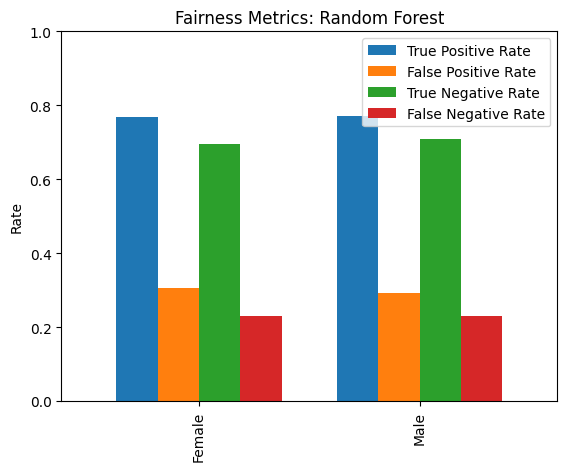

Accuracy for female: 0.7873

Confusion Matrix for XGBoost (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,401,71
Actual Not Employed,140,380


Accuracy for male: 0.7739

Confusion Matrix for XGBoost (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,6047,1390
Actual Not Employed,1705,4545



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.85,0.27,0.73,0.15
Male,0.81,0.27,0.73,0.19


Model Accuracy (XGBoost): 0.775
Model Precision score (XGBoost): 0.778
Model Recall score (XGBoost): 0.815
Model F1 score (XGBoost): 0.796


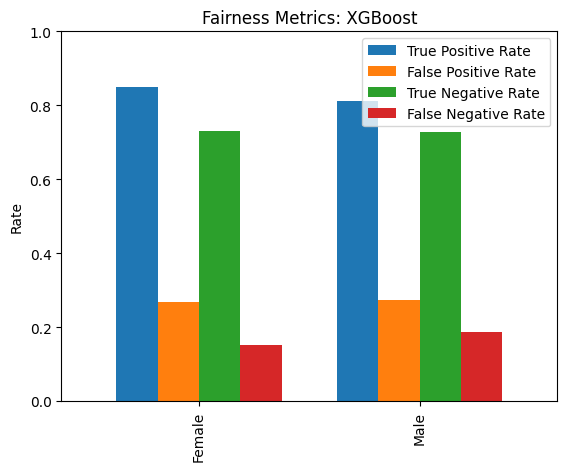

Accuracy for female: 0.7994

Confusion Matrix for SVM (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,393,79
Actual Not Employed,120,400


Accuracy for male: 0.7813

Confusion Matrix for SVM (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5855,1582
Actual Not Employed,1412,4838



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.83,0.23,0.77,0.17
Male,0.79,0.23,0.77,0.21


Model Accuracy (SVM): 0.782
Model Precision score (SVM): 0.803
Model Recall score (SVM): 0.79
Model F1 score (SVM): 0.796


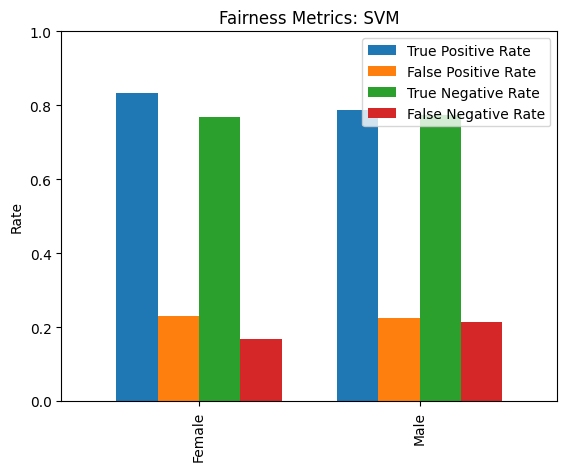

In [128]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

# Logistic Regression
lr_model_egr = ExponentiatedGradient(
    estimator=LogisticRegression(solver='liblinear', random_state=42),
    constraints=DemographicParity()
).fit(X_train_scaled, y_train, sensitive_features=gender_train)
y_pred_lr = lr_model_egr.predict(X_test_scaled)
sp_lg, TPR_lr, FPR_lr = evaluate_fairness(y_test, y_pred_lr, "Logistic Regression")

# Random Forest
rf_model_egr = ExponentiatedGradient(
    estimator=RandomForestClassifier(n_estimators=300, random_state=42),
    constraints=DemographicParity()
).fit(X_train_scaled, y_train, sensitive_features=gender_train)
y_pred_rf = rf_model_egr.predict(X_test_scaled)
sp_rf, TPR_rf, FPR_rf = evaluate_fairness(y_test, y_pred_rf, "Random Forest")
'''
# Gradient Boosting
gbc_model_egr = ExponentiatedGradient(
    estimator=GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42),
    constraints=DemographicParity()
).fit(X_train_scaled, y_train, sensitive_features=gender_train)
y_pred_gbc = gbc_model_egr.predict(X_test_scaled)
sp_gbc, TPR_gbc, FPR_gbc = evaluate_fairness(y_test, y_pred_gbc, "Gradient Boosting")
'''
# XGBoost
xgb_model_egr = ExponentiatedGradient(
    estimator=XGBClassifier(n_estimators=300, random_state=42),
    constraints=DemographicParity()
).fit(X_train_scaled, y_train, sensitive_features=gender_train)
y_pred_xgb = xgb_model_egr.predict(X_test_scaled)
sp_xgb, TPR_xgb, FPR_xgb = evaluate_fairness(y_test, y_pred_xgb, "XGBoost")

# SVM
svm_model_egr = ExponentiatedGradient(
    estimator=LinearSVC(random_state=42, dual=False),
    constraints=DemographicParity()
).fit(X_train_scaled, y_train, sensitive_features=gender_train)
y_pred_svm = svm_model_egr.predict(X_test_scaled)
sp_svm, TPR_svm, FPR_svm = evaluate_fairness(y_test, y_pred_svm, "SVM")

# Statistical Parity Difference

### $$SPD = Pr(\hat{Y} = 1 \mid D = \text{unprivileged}) - Pr(\hat{Y} = 1 \mid D = \text{privileged})$$

In [129]:
SPD_in_lg = round(sp_lg[0] - sp_lg[1], 4)
SPD_in_rf = round(sp_rf[0] - sp_rf[1], 4)
#SPD_in_gbc = round(sp_gbc[0] - sp_gbc[1], 4)
SPD_in_xgb = round(sp_xgb[0] - sp_xgb[1], 4)
SPD_in_svm = round(sp_svm[0] - sp_svm[1], 4)
print(f'Logistic Regression -> {SPD_in_lg} \nRandom Forest -> {SPD_in_rf} \nXGBoost -> {SPD_in_xgb} \nSVM -> {SPD_in_svm}')

Logistic Regression -> -0.0151 
Random Forest -> -0.0255 
XGBoost -> -0.021 
SVM -> -0.0138


# Disparate Impact
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [130]:
DI_in_lg = round(sp_lg[0] / sp_lg[1], 4)
DI_in_rf = round(sp_rf[0] / sp_rf[1], 4)
#DI_in_gbc = round(sp_gbc[0] / sp_gbc[1], 4)
DI_in_xgb = round(sp_xgb[0] / sp_xgb[1], 4)
DI_in_svm = round(sp_svm[0] / sp_svm[1], 4)
print(f'Logistic Regression -> {DI_in_lg} \nRandom Forest -> {DI_in_rf} \nXGBoost -> {DI_in_xgb} \nSVM -> {DI_in_svm}')

Logistic Regression -> 0.9719 
Random Forest -> 0.9538 
XGBoost -> 0.9629 
SVM -> 0.974


# Equal Opportunity
### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [131]:
EOD_in_lg = round(TPR_lr[0] - TPR_lr[1], 4)
EOD_in_rf = round(TPR_rf[0] - TPR_rf[1], 4)
#EOD_in_gbc = round(TPR_gbc[0] - TPR_gbc[1], 4)
EOD_in_xgb = round(TPR_xgb[0] - TPR_xgb[1], 4)
EOD_in_svm = round(TPR_svm[0] - TPR_svm[1], 4)
print(f'Logistic Regression -> {EOD_in_lg} \nRandom Forest -> {EOD_in_rf} \nXGBoost -> {EOD_in_xgb} \nSVM -> {EOD_in_svm}')

Logistic Regression -> 0.0479 
Random Forest -> -0.0015 
XGBoost -> 0.0365 
SVM -> 0.0453


# Equalized Odds
### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [132]:
AAOD_in_lg = round(((TPR_lr[0] - TPR_lr[1]) + (FPR_lr[0] - FPR_lr[1])) / 2, 4)
AAOD_in_rf = round(((TPR_rf[0] - TPR_rf[1]) + (FPR_rf[0] - FPR_rf[1])) / 2, 4)
#AAOD_in_gbc = round(((TPR_gbc[0] - TPR_gbc[1]) + (FPR_gbc[0] - FPR_gbc[1])) / 2, 4)
AAOD_in_xgb = round(((TPR_xgb[0] - TPR_xgb[1]) + (FPR_xgb[0] - FPR_xgb[1])) / 2, 4)
AAOD_in_svm = round(((TPR_svm[0] - TPR_svm[1]) + (FPR_svm[0] - FPR_svm[1])) / 2, 4)
print(f'Logistic Regression -> {AAOD_in_lg} \nRandom Forest -> {AAOD_in_rf} \nXGBoost -> {AAOD_in_xgb} \nSVM -> {AAOD_in_svm}')

Logistic Regression -> 0.0239 
Random Forest -> 0.0065 
XGBoost -> 0.0165 
SVM -> 0.0251


# Post Processing (ThresholdOptimizer)

Accuracy for female: 0.7944

Confusion Matrix for Logistic Regression (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,414,58
Actual Not Employed,146,374


Accuracy for male: 0.7843

Confusion Matrix for Logistic Regression (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,6161,1276
Actual Not Employed,1676,4574



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.88,0.28,0.72,0.12
Male,0.83,0.27,0.73,0.17


Model Accuracy (Logistic Regression): 0.785
Model Precision score (Logistic Regression): 0.783
Model Recall score (Logistic Regression): 0.831
Model F1 score (Logistic Regression): 0.806


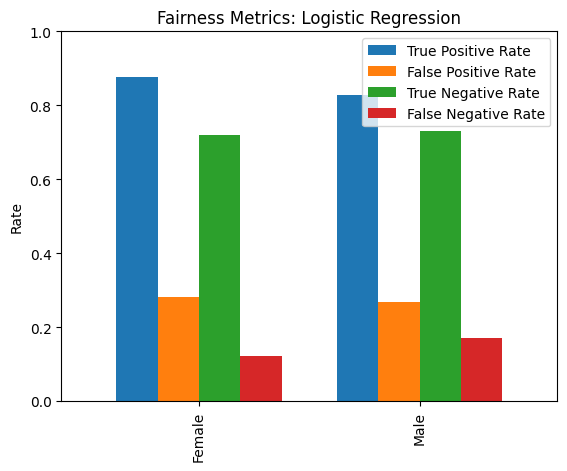

Accuracy for female: 0.7248

Confusion Matrix for Random Forest (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,406,66
Actual Not Employed,207,313


Accuracy for male: 0.7384

Confusion Matrix for Random Forest (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5516,1921
Actual Not Employed,1659,4591



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.86,0.40,0.60,0.14
Male,0.74,0.27,0.73,0.26


Model Accuracy (Random Forest): 0.738
Model Precision score (Random Forest): 0.76
Model Recall score (Random Forest): 0.749
Model F1 score (Random Forest): 0.755


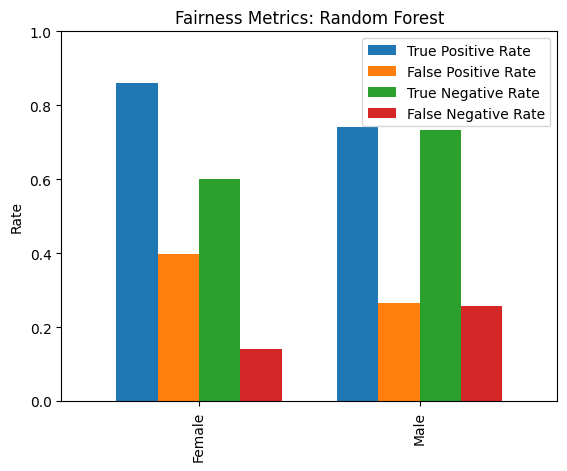

Accuracy for female: 0.7863

Confusion Matrix for XGBoost (Gender = Female)


c:\Users\allah\AppData\Local\Programs\Python\Python312\Lib\site-packages\fairlearn\postprocessing\_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.         1.         0.         1.         0.         0.
 1.         0.         0.         1.         1.         1.
 1.         0.         1.         1.         0.         0.
 0.         1.         1.         0.         0.33434899 1.
 0.         1.         0.         0.         0.         0.
 1.         0.         0.         0.         0.         0.
 1.         0.         1.         1.         0.33434899 0.
 1.         0.         0.         0.         1.         0.
 1.         1.         0.         1.         0.         0.
 0.         0.         0.         0.         0.33434899 1.
 0.         1.         1.         1.         0.         0.33434899
 1.         1.         0.         0.         1.         1.
 0.         1.         

,Predicted Employed,Predicted Not Employed
Actual Employed,407,65
Actual Not Employed,147,373


Accuracy for male: 0.7745

Confusion Matrix for XGBoost (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,6067,1370
Actual Not Employed,1716,4534



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.86,0.28,0.72,0.14
Male,0.82,0.27,0.73,0.18


Model Accuracy (XGBoost): 0.775
Model Precision score (XGBoost): 0.777
Model Recall score (XGBoost): 0.819
Model F1 score (XGBoost): 0.797


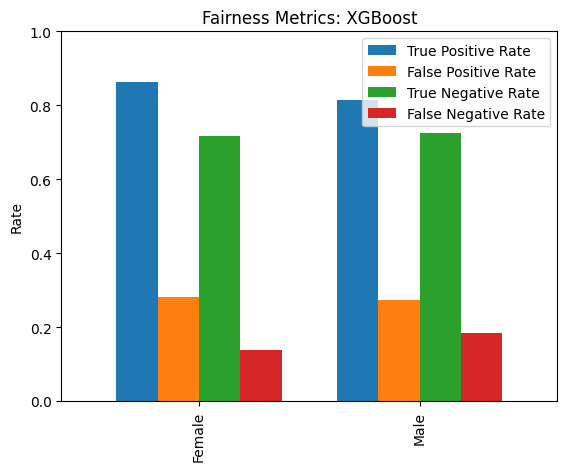

Accuracy for female: 0.7933

Confusion Matrix for SVM (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,413,59
Actual Not Employed,146,374


Accuracy for male: 0.7853

Confusion Matrix for SVM (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,6114,1323
Actual Not Employed,1616,4634



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.88,0.28,0.72,0.12
Male,0.82,0.26,0.74,0.18


Model Accuracy (SVM): 0.786
Model Precision score (SVM): 0.787
Model Recall score (SVM): 0.825
Model F1 score (SVM): 0.806


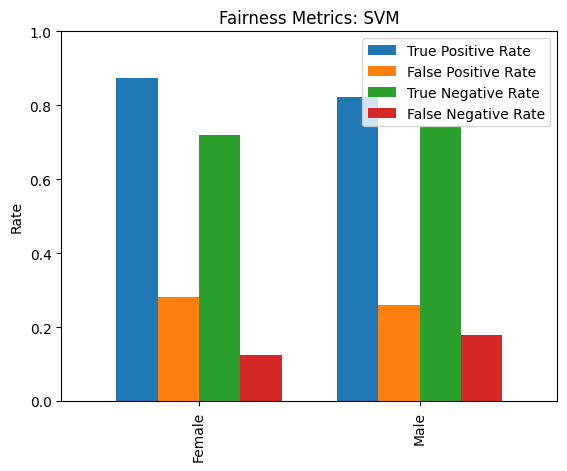

Accuracy for female: 0.7611

Confusion Matrix for KNN (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,382,90
Actual Not Employed,147,373


Accuracy for male: 0.7552

Confusion Matrix for KNN (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,5814,1623
Actual Not Employed,1727,4523



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.81,0.28,0.72,0.19
Male,0.78,0.28,0.72,0.22


Model Accuracy (KNN): 0.756
Model Precision score (KNN): 0.768
Model Recall score (KNN): 0.783
Model F1 score (KNN): 0.776


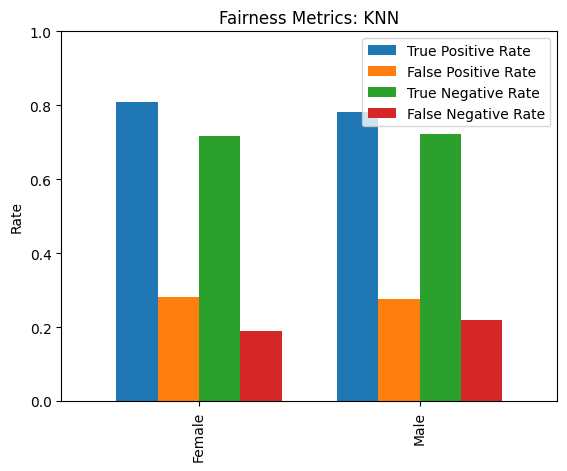

Accuracy for female: 0.7873

Confusion Matrix for Naive Bayes (Gender = Female)


,Predicted Employed,Predicted Not Employed
Actual Employed,411,61
Actual Not Employed,150,370


Accuracy for male: 0.7812

Confusion Matrix for Naive Bayes (Gender = Male)


,Predicted Employed,Predicted Not Employed
Actual Employed,6098,1339
Actual Not Employed,1656,4594



Rates:


,True Positive Rate,False Positive Rate,True Negative Rate,False Negative Rate
Female,0.87,0.29,0.71,0.13
Male,0.82,0.26,0.74,0.18


Model Accuracy (Naive Bayes): 0.782
Model Precision score (Naive Bayes): 0.783
Model Recall score (Naive Bayes): 0.823
Model F1 score (Naive Bayes): 0.802


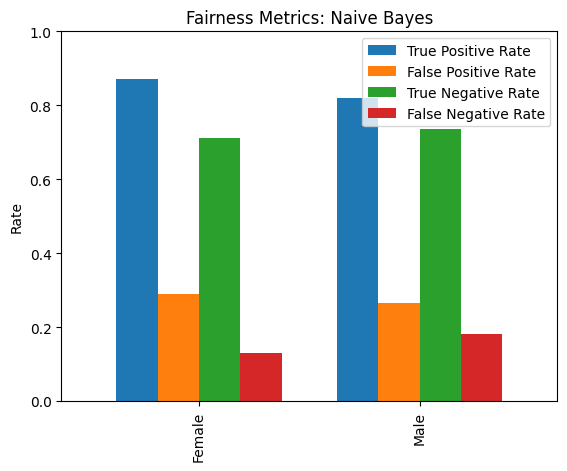

In [133]:
from fairlearn.postprocessing import ThresholdOptimizer

# Logistic Regression
lr_model = ThresholdOptimizer(
    estimator=LogisticRegression(solver='liblinear', random_state=42),
    constraints="demographic_parity"
).fit(X_train_scaled, y_train, sensitive_features=gender_train)
y_pred_lr = lr_model.predict(X_test_scaled, sensitive_features=gender_test)
sp_lg, TPR_lr, FPR_lr = evaluate_fairness(y_test, y_pred_lr, "Logistic Regression")

# Random Forest
rf_model = ThresholdOptimizer(
    estimator=RandomForestClassifier(n_estimators=300, random_state=42),
    constraints="demographic_parity"
).fit(X_train_scaled, y_train, sensitive_features=gender_train)
y_pred_rf = rf_model.predict(X_test_scaled, sensitive_features=gender_test)
sp_rf, TPR_rf, FPR_rf = evaluate_fairness(y_test, y_pred_rf, "Random Forest")

'''
# Gradient Boosting
gbc_model = ThresholdOptimizer(
    estimator=GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42),
    constraints="demographic_parity"
).fit(X_train_scaled, y_train, sensitive_features=gender_train)
y_pred_gbc = gbc_model.predict(X_test_scaled, sensitive_features=gender_test)
sp_gbc, TPR_gbc, FPR_gbc = evaluate_fairness(y_test, y_pred_gbc, "Gradient Boosting")
'''

#XGBoost
xgb_model_egr = ThresholdOptimizer(
    estimator=XGBClassifier(n_estimators=300, random_state=42),
    constraints="demographic_parity"
).fit(X_train_scaled, y_train, sensitive_features=gender_train)
y_pred_xgb = xgb_model_egr.predict(X_test_scaled, sensitive_features=gender_test)
sp_xgb, TPR_xgb, FPR_xgb = evaluate_fairness(y_test, y_pred_xgb, "XGBoost")

# SVM
svm_model_egr = ThresholdOptimizer(
    estimator=LinearSVC(random_state=42, dual=False),
    constraints="demographic_parity"
).fit(X_train_scaled, y_train, sensitive_features=gender_train)
y_pred_svm = svm_model_egr.predict(X_test_scaled, sensitive_features=gender_test)
sp_svm, TPR_svm, FPR_svm = evaluate_fairness(y_test, y_pred_svm, "SVM")

# KNN
knn_model_egr = ThresholdOptimizer(
    estimator=KNeighborsClassifier(),
    constraints="demographic_parity"
).fit(X_train_scaled, y_train, sensitive_features=gender_train)
y_pred_knn = knn_model_egr.predict(X_test_scaled, sensitive_features=gender_test)
sp_knn, TPR_knn, FPR_knn = evaluate_fairness(y_test, y_pred_knn, "KNN")

# Naive Bayes
nb = ThresholdOptimizer(
    estimator=GaussianNB(),
    constraints="demographic_parity"
).fit(X_train, y_train, sensitive_features=gender_train)
y_pred_nb = nb.predict(X_test, sensitive_features=gender_test)
sp_nb, TPR_nb, FPR_nb = evaluate_fairness(y_test, y_pred_nb, "Naive Bayes")

# Statistical Parity Difference

### $$SPD = Pr(\hat{Y} = 1 \mid D = \text{unprivileged}) - Pr(\hat{Y} = 1 \mid D = \text{privileged})$$

In [134]:
SPD_post_lg = round(sp_lg[0] - sp_lg[1], 4)
SPD_post_rf = round(sp_rf[0] - sp_rf[1], 4)
#SPD_post_gbc = round(sp_gbc[0] - sp_gbc[1], 4)
SPD_post_xgb = round(sp_xgb[0] - sp_xgb[1], 4)
SPD_post_svm = round(sp_svm[0] - sp_svm[1], 4)
SPD_post_knn = round(sp_knn[0] - sp_knn[1], 4)
SPD_post_nb = round(sp_nb[0] - sp_nb[1], 4)
print(f'Logistic Regression -> {SPD_post_lg} \nRandom Forest -> {SPD_post_rf} \nXGBoost -> {SPD_post_xgb} \nSVM -> {SPD_post_svm} \nKNN -> {SPD_post_knn} \nNaive Bayes -> {SPD_post_nb}')

Logistic Regression -> -0.0081 
Random Forest -> 0.0937 
XGBoost -> -0.0102 
SVM -> -0.0013 
KNN -> -0.0177 
Naive Bayes -> -0.001


# Disparate Impact
### $$DI = \frac{Pr(\hat{Y} = 1 \mid D = \text{unprivileged})}{Pr(\hat{Y} = 1 \mid D = \text{privileged})}$$ $$DI = \frac{\text{Selection Rate for Females}}{\text{Selection Rate for Males}}$$

In [135]:
DI_post_lg = round(sp_lg[0] / sp_lg[1], 4)
DI_post_rf = round(sp_rf[0] / sp_rf[1], 4)
#DI_post_gbc = round(sp_gbc[0] / sp_gbc[1], 4)
DI_post_xgb = round(sp_xgb[0] / sp_xgb[1], 4)
DI_post_svm = round(sp_svm[0] / sp_svm[1], 4)
DI_post_knn = round(sp_knn[0] / sp_knn[1], 4)
DI_post_nb = round(sp_nb[0] / sp_nb[1], 4)
print(f'Logistic Regression -> {DI_post_lg} \nRandom Forest -> {DI_post_rf} \nXGBoost -> {DI_post_xgb} \nSVM -> {DI_post_svm} \nKNN -> {DI_post_knn}  \nNaive Bayes -> {DI_post_nb}')

Logistic Regression -> 0.9859 
Random Forest -> 1.1788 
XGBoost -> 0.9821 
SVM -> 0.9978 
KNN -> 0.9679  
Naive Bayes -> 0.9982


# Equal Opportunity
### $$\text{Equal Opportunity} = (TPR_{\text{Female}} - TPR_{\text{Male}})$$

In [136]:
EOD_post_lg = round(TPR_lr[0] - TPR_lr[1], 4)
EOD_post_rf = round(TPR_rf[0] - TPR_rf[1], 4)
#EOD_post_gbc = round(TPR_gbc[0] - TPR_gbc[1], 4)
EOD_post_xgb = round(TPR_xgb[0] - TPR_xgb[1], 4)
EOD_post_svm = round(TPR_svm[0] - TPR_svm[1], 4)
EOD_post_knn = round(TPR_knn[0] - TPR_knn[1], 4)
EOD_post_nb = round(TPR_nb[0] - TPR_nb[1], 4)
print(f'Logistic Regression -> {EOD_post_lg} \nRandom Forest -> {EOD_post_rf} \nXGBoost -> {EOD_post_xgb} \nSVM -> {EOD_post_svm} \nKNN -> {EOD_post_knn} \nNaive Bayes -> {EOD_post_nb}')

Logistic Regression -> 0.0487 
Random Forest -> 0.1185 
XGBoost -> 0.0465 
SVM -> 0.0529 
KNN -> 0.0276 
Naive Bayes -> 0.0508


# Equalized Odds
### $$\text{Equalized Odds} = \frac{(TPR_{\text{Female}} - TPR_{\text{Male}}) + (FPR_{\text{Female}} - FPR_{\text{Male}})}{2}$$

In [137]:
AAOD_post_lg = round(((TPR_lr[0] - TPR_lr[1]) + (FPR_lr[0] - FPR_lr[1])) / 2, 4)
AAOD_post_rf = round(((TPR_rf[0] - TPR_rf[1]) + (FPR_rf[0] - FPR_rf[1])) / 2, 4)
#AAOD_post_gbc = round(((TPR_gbc[0] - TPR_gbc[1]) + (FPR_gbc[0] - FPR_gbc[1])) / 2, 4)
AAOD_post_xgb = round(((TPR_xgb[0] - TPR_xgb[1]) + (FPR_xgb[0] - FPR_xgb[1])) / 2, 4)
AAOD_post_svm = round(((TPR_svm[0] - TPR_svm[1]) + (FPR_svm[0] - FPR_svm[1])) / 2, 4)
AAOD_post_knn = round(((TPR_knn[0] - TPR_knn[1]) + (FPR_knn[0] - FPR_knn[1])) / 2, 4)
AAOD_post_nb = round(((TPR_nb[0] - TPR_nb[1]) + (FPR_nb[0] - FPR_nb[1])) / 2, 4)
print(f'Logistic Regression -> {AAOD_post_lg} \nRandom Forest -> {AAOD_post_rf} \nXGBoost -> {AAOD_post_xgb} \nSVM -> {AAOD_post_svm} \nKNN -> {AAOD_post_knn}  \nNaive Bayes -> {AAOD_post_nb}')

Logistic Regression -> 0.0307 
Random Forest -> 0.1256 
XGBoost -> 0.0273 
SVM -> 0.0376 
KNN -> 0.017  
Naive Bayes -> 0.0372
